In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import glob
import polars as pl
from statsmodels.tsa.stattools import adfuller
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
base_path = "/kaggle/input/quantfin/fx_dataset-main/data/"
pairs = ["EUR_USD", "GBP_USD", "USD_JPY", "USD_CNH"]

def load_and_standardize(p):
    print(f"Standardizing {p}...")
    path = os.path.join(base_path, p, f"{p}_S5_*", "*.csv")
    files = glob.glob(path)
    
    return (
        pl.scan_csv(files)
        .select([

            pl.from_epoch(pl.col("utc").cast(pl.Int64).alias("utc"),time_unit="s"),
            pl.col("close").cast(pl.Float32).alias(f"{p}_close"),
            pl.col("volumn").cast(pl.Float32).alias(f"{p}_volumn")
        ])
        .unique(subset=["utc"])
        .sort("utc")
        .collect()
    )

# 1. We load EUR_USD first (it has the most history, starting 2005)
master_df = load_and_standardize("EUR_USD")

# 2. Join the others
for p in ["GBP_USD", "USD_JPY", "USD_CNH"]:
    next_pair = load_and_standardize(p)
    print(f"Merging {p}...")
    # 'outer' join , so we don't lose rows where EUR_USD didn't trade
    master_df = master_df.join(next_pair, on="utc", how="outer_coalesce")


print("Finalizing 5-second grid...")
master_df = (
    master_df
    .sort("utc")
    .upsample(time_column="utc", every="5s")
    .with_columns([
        pl.col("^.*_close$").fill_null(strategy="forward").fill_null(strategy="backward"),
        pl.col("^.*_volumn$").fill_null(0)
    ])
)

print(f"Final Count: {len(master_df)} rows")
master_df.write_parquet("master_data.parquet")

Standardizing EUR_USD...
Standardizing GBP_USD...
Merging GBP_USD...


/tmp/ipykernel_583/1234206049.py:30: DeprecationWarning: Use of `how='outer_coalesce'` should be replaced with `how='full', coalesce=True`.
  master_df = master_df.join(next_pair, on="utc", how="outer_coalesce")


Standardizing USD_JPY...
Merging USD_JPY...
Standardizing USD_CNH...
Merging USD_CNH...
Finalizing 5-second grid...
Final Count: 120362749 rows


In [3]:
print(master_df)

shape: (120_362_749, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ utc       ┆ EUR_USD_c ┆ EUR_USD_v ┆ GBP_USD_c ┆ … ┆ USD_JPY_c ┆ USD_JPY_v ┆ USD_CNH_c ┆ USD_CNH_ │
│ ---       ┆ lose      ┆ olumn     ┆ lose      ┆   ┆ lose      ┆ olumn     ┆ lose      ┆ volumn   │
│ datetime[ ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ μs]       ┆ f32       ┆ f32       ┆ f32       ┆   ┆ f32       ┆ f32       ┆ f32       ┆ f32      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2005-01-0 ┆ 1.356     ┆ 1.0       ┆ 1.9188    ┆ … ┆ 102.51000 ┆ 0.0       ┆ 6.565     ┆ 0.0      │
│ 2         ┆           ┆           ┆           ┆   ┆ 2         ┆           ┆           ┆          │
│ 18:38:20  ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ 2005-01-0 ┆ 1.356     ┆ 0.0       ┆ 1.9188    ┆ … ┆ 102.51000 ┆ 0

# We will check only cointegration of pairs not correlation

In [9]:
def cointegration_test(df, pairA, pairB, sample_size=100000):
    print(f"Testing {pairA} vs {pairB}...")
    

    data = (
        df.select([
            pl.col(f"{pairA}_close").log().alias("x"),
            pl.col(f"{pairB}_close").log().alias("y")
        ])
        .tail(sample_size) 
        .drop_nulls()
    )

    x = data["x"].to_numpy()
    y = data["y"].to_numpy()

    # OLS hedge ratio
    beta = np.polyfit(x, y, 1)[0]
    spread = y - beta * x

    # ADF test
    adf_stat, p_value, _, _, _, _ = adfuller(spread, autolag="AIC")

    # Half-life estimation
    spread_lag = spread[:-1]
    spread_ret = np.diff(spread)
    hl_beta = np.polyfit(spread_lag, spread_ret, 1)[0]
    half_life = -np.log(2) / hl_beta if hl_beta < 0 else np.inf

    return {
        "pairA": pairA,
        "pairB": pairB,
        "hedge_ratio": beta,
        "adf_stat": adf_stat,
        "p_value": p_value,
        "half_life": half_life,
        "is_cointegrated": (p_value < 0.05)
    }

# 120 million rows -> 10 million rows (1-minute bars)
ad=master_df
test_df = (
    ad
    .group_by_dynamic("utc", every="1m")
    .agg(pl.all().last())
)

In [10]:

pairs = [
    ("EUR_USD", "GBP_USD"),
    ("USD_JPY", "USD_CNH"), # Though we needn't check for this one as it's not a “Same base or same quote currency pair” 
    #We won't trade it. It may be mathematically tradeable but not economially
]

results = []
for a, b in pairs:
    res = cointegration_test(test_df, a, b)
    if res:
        results.append(res)

cointegration_results = pl.DataFrame(results)
cointegration_results


Testing EUR_USD vs GBP_USD...
Testing USD_JPY vs USD_CNH...


/tmp/ipykernel_300/144628030.py:18: RankWarning: Polyfit may be poorly conditioned
  beta = np.polyfit(x, y, 1)[0]


pairA,pairB,hedge_ratio,adf_stat,p_value,half_life,is_cointegrated
str,str,f64,f64,f64,f64,i64
"""EUR_USD""","""GBP_USD""",0.467754,-3.472834,0.008713,3309.880245,1
"""USD_JPY""","""USD_CNH""",0.197698,-2.20383,0.204858,6014.813455,0


In [4]:
def run_beta_vol_neutral_engine(
    df: pl.DataFrame,
    pairA: str,
    pairB: str,
    beta: float,
    vol_window: int,
    z_window: int,
    entry_z: float,
    exit_z: float
):
    """
    β + Volatility Neutral Statistical Arbitrage Engine
    """

    print(f"--- Running β + Vol-Neutral Engine: {pairA} vs {pairB} ---")

    
    df = df.with_columns([
        pl.col(f"{pairA}_close").log().alias("logA"),
        pl.col(f"{pairB}_close").log().alias("logB"),
    ]).with_columns([
        pl.col("logA").diff().alias("retA"),
        pl.col("logB").diff().alias("retB"),
    ])


    df = df.with_columns([
        pl.col("retA").rolling_std(vol_window).alias("volA"),
        pl.col("retB").rolling_std(vol_window).alias("volB"),
    ])

    
    df = df.with_columns([
        (pl.col("logA") - beta * pl.col("logB")).alias("spread")
    ])


    df = df.with_columns([
        (
            (pl.col("spread") - pl.col("spread").rolling_mean(z_window)) /
            pl.col("spread").rolling_std(z_window)
        ).alias("z")
    ])

    signal = (
        pl.when(pl.col("z") > entry_z).then(-1)
        .when(pl.col("z") < -entry_z).then(1)
        .when(pl.col("z").abs() < exit_z).then(0)
        .otherwise(None)
    )

    df = df.with_columns([
        signal.alias("raw_pos")
    ]).with_columns([
        pl.col("raw_pos")
        .fill_null(strategy="forward")
        .fill_null(0)
        .alias("pos")
    ])
    

    df = df.with_columns([
        (1 / pl.col("volA")).replace([float("inf")], None).fill_null(0).alias("inv_volA"),
        (1 / pl.col("volB")).replace([float("inf")], None).fill_null(0).alias("inv_volB"),
    ])

    df = df.with_columns([
        (pl.col("inv_volA") / (pl.col("inv_volA") + beta * pl.col("inv_volB")))
        .fill_nan(0)
        .alias("wA"),
        (beta * pl.col("inv_volB") / (pl.col("inv_volA") + beta * pl.col("inv_volB")))
        .fill_nan(0)
        .alias("wB"),
    ])


    df = df.with_columns([
        (pl.col("pos") * pl.col("wA")).alias("pos_A"),
        (-pl.col("pos") * pl.col("wB")).alias("pos_B") 
    ])

    df = df.with_columns([
        (pl.col("pos").shift(1) * pl.col("wA").shift(1) * pl.col("retA")).alias("pnlA"),
        (-pl.col("pos").shift(1) * pl.col("wB").shift(1) * pl.col("retB")).alias("pnlB"),
    ])

    df = df.with_columns([
        (pl.col("pnlA") + pl.col("pnlB")).fill_null(0).alias("period_pnl")
    ])
    df=df.with_columns([
        pl.col("period_pnl").cum_sum().alias("equity")
    ])

    return df


--- Running β + Vol-Neutral Engine: EUR_USD vs GBP_USD ---


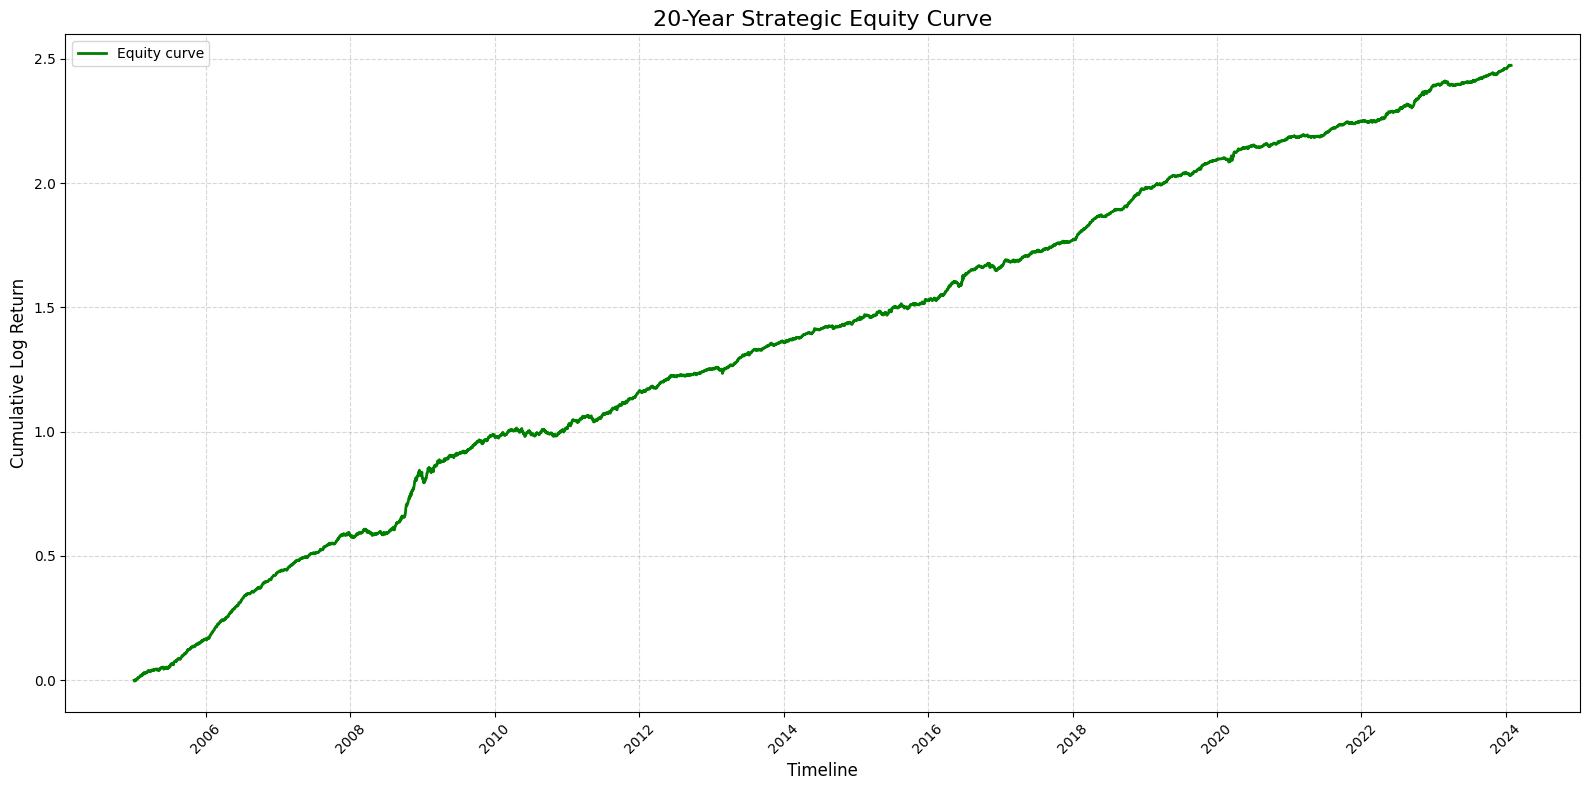

In [5]:
result = run_beta_vol_neutral_engine(
    master_df,
    pairA="EUR_USD",
    pairB="GBP_USD",
    beta=0.467754,   # from table
    vol_window=720,
    z_window=3000,
    entry_z=2.5,
    exit_z=0.3
)
daily_results = (
    result
    .group_by_dynamic("utc", every="1d")
    .agg([
        pl.col("period_pnl").sum().alias("daily_total")
    ])
    .with_columns([
        pl.col("daily_total").cum_sum().alias("equity")
    ])
)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 2. Plotting
plt.figure(figsize=(16, 8))



plt.plot(daily_results["utc"], daily_results["equity"], label="Equity curve", color='green', linewidth=2)

# Formatting
plt.title("20-Year Strategic Equity Curve", fontsize=16)
plt.ylabel("Cumulative Log Return", fontsize=12)
plt.xlabel("Timeline", fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc="upper left")


plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Evaluation metrics

In [6]:
def evaluate_submission_readiness(res):
    
    bars_per_year = 12 * 60 * 24 * 365 
    annualization_factor = np.sqrt(bars_per_year)
    
    mean_pnl = res['period_pnl'].mean()
    std_pnl = res['period_pnl'].std()
    

    sharpe = (mean_pnl / std_pnl) * annualization_factor if std_pnl > 0 else 0
    

    equity = res['equity']
    rolling_max = equity.cum_max()
    drawdown = equity - rolling_max
    max_drawdown = drawdown.min()
    

    net_exposure = (res['pos_A'] + res['pos_B']).mean()
    

    turnover = (res['pos_A'].diff().abs().fill_null(0) + 
                res['pos_B'].diff().abs().fill_null(0)).mean()
    
    print(f"--- Final Evaluation Metrics ---")
    print(f"Sharpe Ratio: {sharpe:.4f}")
    print(f"Max Drawdown: {max_drawdown:.4f}")
    print(f"Avg Net Exposure: {net_exposure:.6f}")
    print(f"Turnover Score: {turnover:.6f}")
    
    return sharpe, max_drawdown, net_exposure, turnover

In [11]:
a,b,c,d=evaluate_submission_readiness(result)

--- Final Evaluation Metrics ---
Sharpe Ratio: 3.0272
Max Drawdown: -0.0576
Avg Net Exposure: 0.045610
Turnover Score: 0.000861


# Save output

In [10]:
import polars as pl

# Convert result to LazyFrame
lazy_res = result.lazy()


output_A = lazy_res.select([
    pl.col("utc"),
    pl.lit("EURUSD").alias("pair"),
    (pl.col("pos") * pl.col("wA")).clip(-1, 1).fill_null(0).alias("position"),
    pl.col("pnlA").fill_null(0).alias("pnl")
])


output_B = lazy_res.select([
    pl.col("utc"),
    pl.lit("GBPUSD").alias("pair"),
    (-pl.col("pos") * pl.col("wB")).clip(-1, 1).fill_null(0).alias("position"),
    pl.col("pnlB").fill_null(0).alias("pnl")
])


final_lazy = pl.concat([output_A, output_B])

print("Streaming to CSV (constant memory)...")


final_lazy.sink_csv("strategy_output.csv")

print("Done.")


Streaming to CSV (constant memory)...
Done.
